# Tugas 2 - Klasifikasi Diabetes dengan Naive Bayes dan Logistic Regression

| Nama | NRP |
|------|-----|
| Raihan Nurhakim| 5054251030|

## Deskripsi Tugas
Pada tugas ini, kita akan menggunakan Pima Indians Diabetes Dataset. Dataset bisa diakses melalui link berikut:\
https://www.kaggle.com/datasets/jamaltariqcheema/pima-indians-diabetes-dataset

Tujuan utama dari tugas ini adalah membangun model Naive Bayes dan Logistic Regression untuk mengklasifikasikan apakah seorang pasien menderita diabetes atau tidak.

Langkah-langkah yang harus dilakukan antara lain:
1. Persiapan Dataset dan Eksplorasi Awal
   - Memuat dataset, melihat struktur data, dan distribusi label.
2. Preprocessing
   - Memproses data agar siap digunakan dalam membangun model.
3. Eksperimen Model
   - Bangun model Gaussian Naive Bayes dan Logistic Regression.
4. Evaluasi Model
   - Hitung metrik evaluasi dan visualisasikan hasilnya.
5. Analisis dan Kesimpulan
   - Bandingkan hasil kedua model dan berikan kesimpulan.

# 1. Persiapan Dataset dan Eksplorasi Awal

In [1]:
# Import library yang dibutuhkan (pandas, numpy, matplotlib, seaborn, sklearn, dll)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             roc_curve)

sns.set_theme(style='whitegrid')

In [2]:
# Load dataset dan tampilkan informasi dasar: jumlah baris dan kolom, tipe data, statistik deskriptif, dan jumlah missing value.
df = pd.read_csv('diabetes.csv')

print(f"jumlah baris : {df.shape[0]}")
print(f"jumlah kolom : {df.shape[1]}")
print()
print("Tipe data:")
print(df.dtypes)
print()
print("statistik deskriptif:")
display(df.describe())
print()
print("Jumlah missing value:")
print(df.isnull().sum())

jumlah baris : 768
jumlah kolom : 9

Tipe data:
Pregnancies                   int64
Glucose                       int64
BloodPressure               float64
SkinThickness                 int64
Insulin                     float64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

statistik deskriptif:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.677083,72.389323,29.089844,141.753906,32.434635,0.471876,33.240885,0.348958
std,3.369578,30.464161,12.106039,8.890820,89.100847,6.880498,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,25.000000,102.500000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,28.000000,102.500000,32.050000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,169.500000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000



Jumlah missing value:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


frekuensi:
Outcome
0    500
1    268
Name: count, dtype: int64

proporsi (%):
Outcome
0    65.1
1    34.9
Name: proportion, dtype: float64


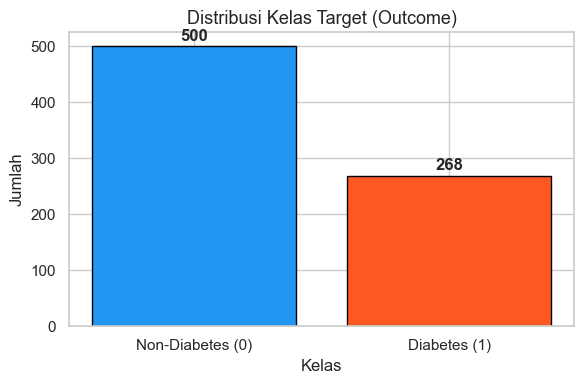

In [3]:
# Tampilkan distribusi kelas target (Outcome) dalam bentuk bar plot.
# Perhatikan apakah dataset ini imbalanced.
outcome_counts = df['Outcome'].value_counts()
outcome_pct    = df['Outcome'].value_counts(normalize=True) * 100

print("frekuensi:")
print(outcome_counts)
print("\nproporsi (%):")
print(outcome_pct.round(2))

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(['Non-Diabetes (0)', 'Diabetes (1)'],
              [outcome_counts[0], outcome_counts[1]],
              color=['#2196F3', '#FF5722'], edgecolor='black')
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            str(int(bar.get_height())), ha='center', va='bottom', fontweight='bold')
ax.set_title('Distribusi Kelas Target (Outcome)', fontsize=13)
ax.set_xlabel('Kelas')
ax.set_ylabel('Jumlah')
plt.tight_layout()
plt.show()

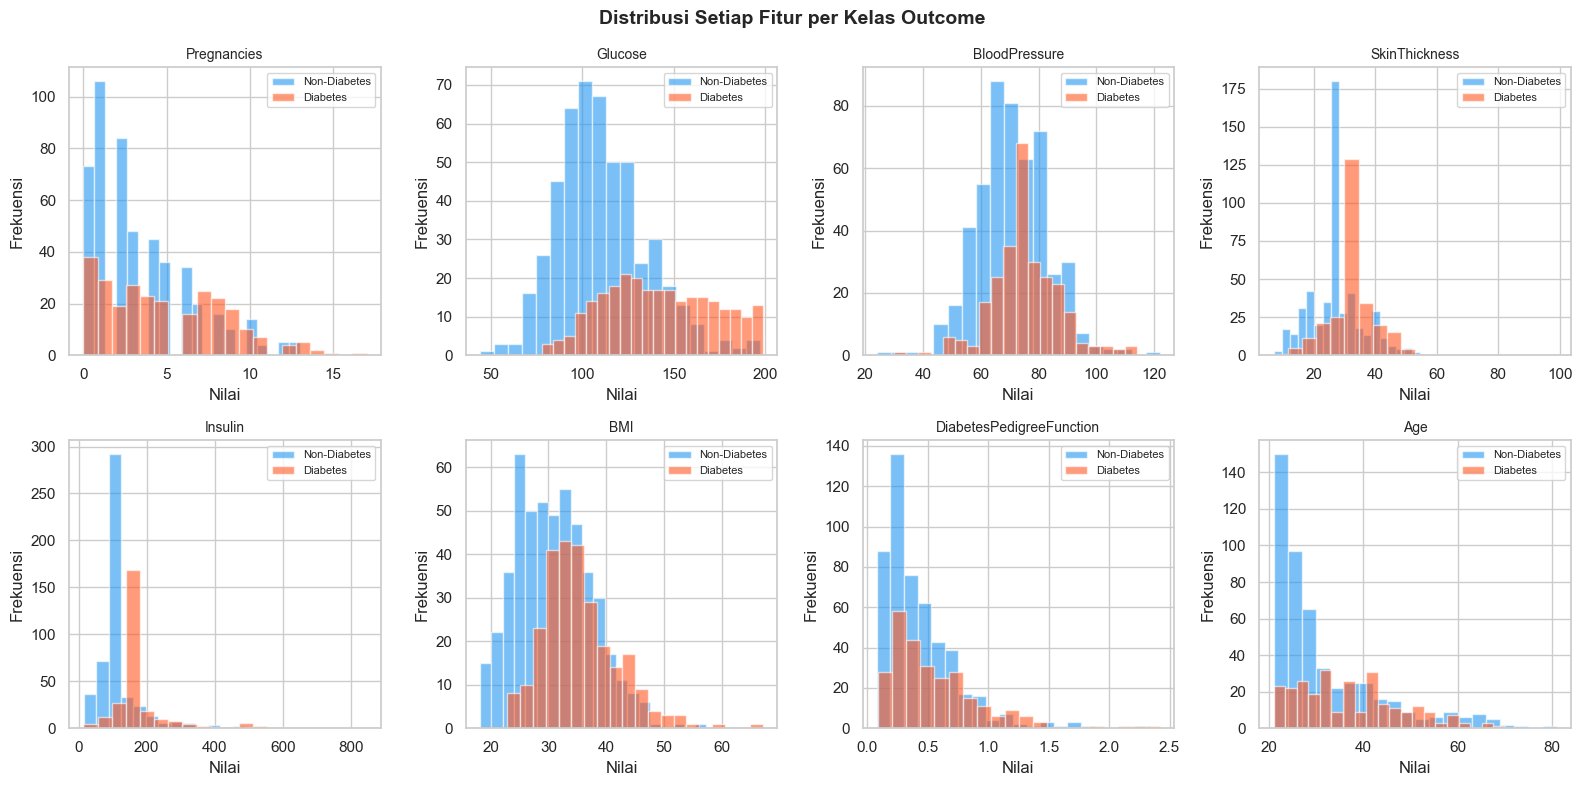

In [4]:
# Tampilkan distribusi setiap fitur menggunakan histogram atau KDE plot, dibedakan berdasarkan kelas Outcome.
features = [c for c in df.columns if c != 'Outcome']
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, feat in enumerate(features):
    for outcome, color, label in [(0, '#2196F3', 'Non-Diabetes'), (1, '#FF5722', 'Diabetes')]:
        subset = df[df['Outcome'] == outcome][feat]
        axes[i].hist(subset, bins=20, alpha=0.6, color=color, label=label, edgecolor='white')
    axes[i].set_title(feat, fontsize=10)
    axes[i].set_xlabel('Nilai')
    axes[i].set_ylabel('Frekuensi')
    axes[i].legend(fontsize=8)

plt.suptitle('Distribusi Setiap Fitur per Kelas Outcome', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

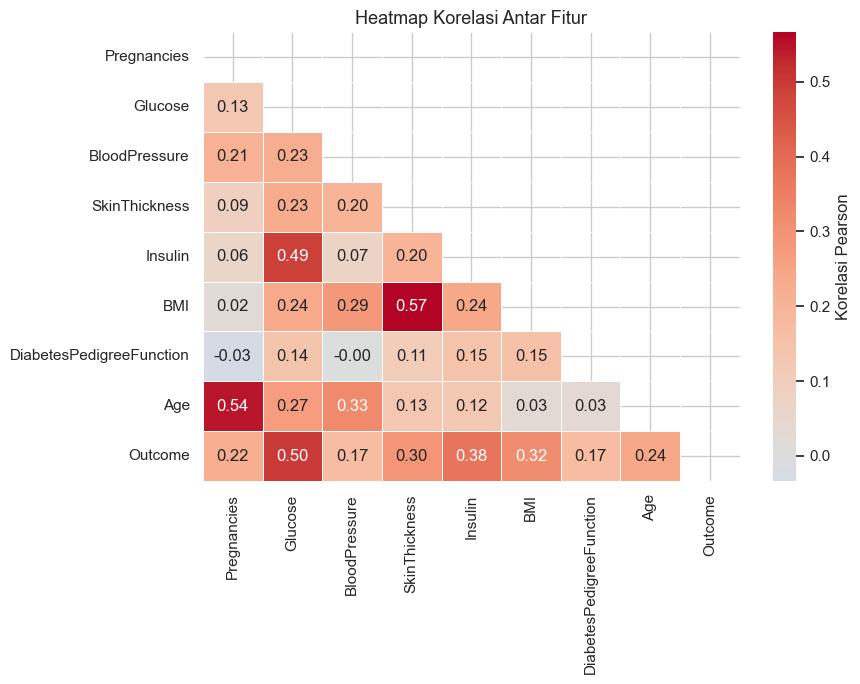

Fitur dengan korelasi tertinggi terhadap Outcome:
Glucose                     0.495990
Insulin                     0.377081
BMI                         0.315577
SkinThickness               0.295138
Age                         0.238356
Pregnancies                 0.221898
BloodPressure               0.174469
DiabetesPedigreeFunction    0.173844
Name: Outcome, dtype: float64


In [5]:
# Tampilkan heatmap korelasi antar fitur.
fig, ax = plt.subplots(figsize=(9, 7))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=ax, linewidths=0.5,
            cbar_kws={'label': 'Korelasi Pearson'})
ax.set_title('Heatmap Korelasi Antar Fitur', fontsize=13)
plt.tight_layout()
plt.show()

print("Fitur dengan korelasi tertinggi terhadap Outcome:")
print(corr['Outcome'].drop('Outcome').sort_values(ascending=False))

## Lakukan Exploratory Data Analysis (EDA) tambahan yang diperlukan.

# 2. Preprocessing

In [6]:
# Beberapa kolom seperti Glucose, BloodPressure, SkinThickness, Insulin, dan BMI memiliki nilai 0 yang secara medis tidak mungkin.
# Identifikasi kolom-kolom tersebut dan hitung jumlah nilai 0 pada masing-masing kolom.
cols_with_impossible_zero = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

print("jumlah nilai 0 pada kolom yang secara medis tidak mungkin:")
for col in cols_with_impossible_zero:
    n_zeros = (df[col] == 0).sum()
    pct = n_zeros / len(df) * 100
    print(f"  {col:<25}: {n_zeros} ({pct:.1f}%)")

jumlah nilai 0 pada kolom yang secara medis tidak mungkin:
  Glucose                  : 0 (0.0%)
  BloodPressure            : 0 (0.0%)
  SkinThickness            : 0 (0.0%)
  Insulin                  : 0 (0.0%)
  BMI                      : 0 (0.0%)


In [7]:
# Tangani nilai 0 tersebut dengan strategi yang sesuai (misalnya imputasi dengan median atau mean).
# Pastikan strategi yang dipilih tidak memperkenalkan data leakage.
df_clean = df.copy()
for col in cols_with_impossible_zero:
    df_clean[col] = df_clean[col].replace(0, np.nan)

print("missing value setelah replace 0 dengan NaN:")
print(df_clean[cols_with_impossible_zero].isnull().sum())

missing value setelah replace 0 dengan NaN:
Glucose          0
BloodPressure    0
SkinThickness    0
Insulin          0
BMI              0
dtype: int64


In [8]:
# Pisahkan fitur (X) dan target (y).
# Bagi data menjadi train set dan test set (misalnya 80:20).
# Gunakan stratify=y agar distribusi kelas tetap proporsional.

X = df_clean.drop(columns=['Outcome'])
y = df_clean['Outcome']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"train size: {X_train.shape[0]} | test size: {X_test.shape[0]}")
print(f"train: {dict(y_train.value_counts())}")
print(f"test: {dict(y_test.value_counts())}")

from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='median')
X_train_imp = pd.DataFrame(imputer.fit_transform(X_train), columns=X.columns)
X_test_imp  = pd.DataFrame(imputer.transform(X_test),      columns=X.columns)

print("\nmissing value train setelah:", X_train_imp.isnull().sum().sum())
print("missing value test setelah: ", X_test_imp.isnull().sum().sum())

train size: 614 | test size: 154
train: {0: np.int64(400), 1: np.int64(214)}
test: {0: np.int64(100), 1: np.int64(54)}

missing value train setelah: 0
missing value test setelah:  0


In [9]:
# Lakukan feature scaling menggunakan StandardScaler.
# Fit hanya pada train set, kemudian transform pada train set dan test set.
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_imp)
X_test_sc  = scaler.transform(X_test_imp)

print(f"mean train (Glucose): {X_train_sc[:, 1].mean():.4f} (seharusnya ~0)")
print(f"std train (Glucose): {X_train_sc[:, 1].std():.4f} (seharusnya ~1)")

mean train (Glucose): -0.0000 (seharusnya ~0)
std train (Glucose): 1.0000 (seharusnya ~1)


# 3. Eksperimen Model

## 3.1 Gaussian Naive Bayes

Gunakan GaussianNB karena semua fitur pada dataset ini bersifat numerik kontinu.

In [10]:
# Inisialisasi dan latih model Gaussian Naive Bayes menggunakan train set.
gnb = GaussianNB()
gnb.fit(X_train_sc, y_train)
print(f"Prior kelas: {dict(zip([0,1], gnb.class_prior_.round(4)))}")

Prior kelas: {0: np.float64(0.6515), 1: np.float64(0.3485)}


In [11]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label dan probabilitas kelas 1 untuk keperluan evaluasi.
y_pred_gnb = gnb.predict(X_test_sc)
y_prob_gnb = gnb.predict_proba(X_test_sc)[:, 1]
print(f"Contoh probabilitas 5 sampel pertama: {y_prob_gnb[:5].round(4)}")

Contoh probabilitas 5 sampel pertama: [0.3946 0.2109 0.2328 0.1853 0.0061]


## 3.2 Logistic Regression

In [12]:
# Inisialisasi dan latih model Logistic Regression menggunakan train set.
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_sc, y_train)
print(f"Iterasi konvergen: {lr.n_iter_[0]}")

Iterasi konvergen: 8


In [13]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label dan probabilitas kelas 1 untuk keperluan evaluasi.
y_pred_lr = lr.predict(X_test_sc)
y_prob_lr = lr.predict_proba(X_test_sc)[:, 1]
print(f"Contoh probabilitas 5 sampel pertama: {y_prob_lr[:5].round(4)}")

Contoh probabilitas 5 sampel pertama: [0.4774 0.0741 0.3701 0.3377 0.032 ]


# 4. Evaluasi Model

In [14]:
# Tampilkan metrik evaluasi untuk setiap model: Accuracy, Precision, Recall, dan F1-Score.
results = {}
for name, yp, ypr in [('GaussianNB', y_pred_gnb, y_prob_gnb), ('LogisticRegression', y_pred_lr,y_prob_lr)]:
    results[name] = {
        'Accuracy':  round(accuracy_score(y_test, yp), 4),
        'Precision': round(precision_score(y_test, yp), 4),
        'Recall':    round(recall_score(y_test, yp), 4),
        'F1-Score':  round(f1_score(y_test, yp), 4),
        'AUC-ROC':   round(roc_auc_score(y_test, ypr), 4),
    }

df_results = pd.DataFrame(results).T
print("=== Tabel Perbandingan Metrik Evaluasi ===")
display(df_results)

=== Tabel Perbandingan Metrik Evaluasi ===


,Accuracy,Precision,Recall,F1-Score,AUC-ROC
GaussianNB,0.7273,0.6034,0.6481,0.6250,0.8017
LogisticRegression,0.7078,0.5882,0.5556,0.5714,0.8263


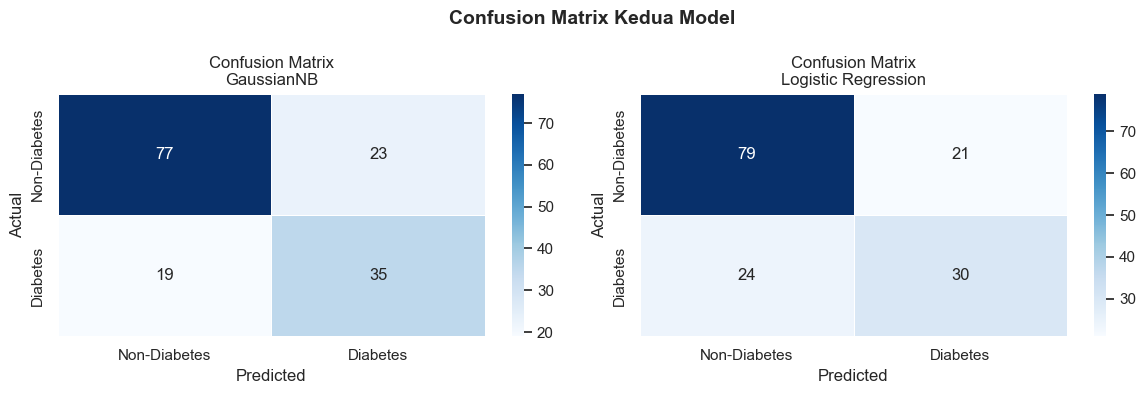

In [15]:
# Tampilkan Confusion Matrix setiap model dalam bentuk heatmap.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, (name, yp) in zip(axes, [('GaussianNB', y_pred_gnb),
                                   ('Logistic Regression', y_pred_lr)]):
    cm = confusion_matrix(y_test, yp)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Non-Diabetes', 'Diabetes'],
                yticklabels=['Non-Diabetes', 'Diabetes'],
                linewidths=0.5)
    ax.set_title(f'Confusion Matrix\n{name}', fontsize=12)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrix Kedua Model', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

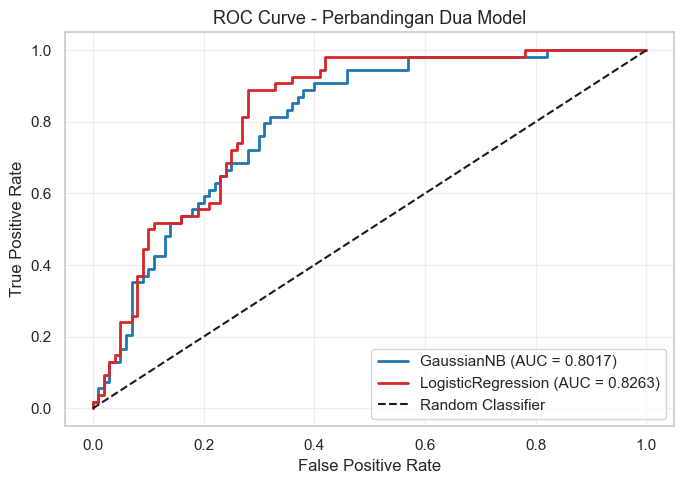

In [16]:
# Tampilkan ROC Curve kedua model dalam satu plot beserta nilai AUC masing-masing.
fig, ax = plt.subplots(figsize=(7, 5))

for (name, ypr), color in zip([('GaussianNB',        y_prob_gnb),
                                ('LogisticRegression', y_prob_lr)],
                               ['#1f77b4', '#d62728']):
    fpr, tpr, _ = roc_curve(y_test, ypr)
    auc = roc_auc_score(y_test, ypr)
    ax.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC = {auc:.4f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random Classifier')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curve - Perbandingan Dua Model', fontsize=13)
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

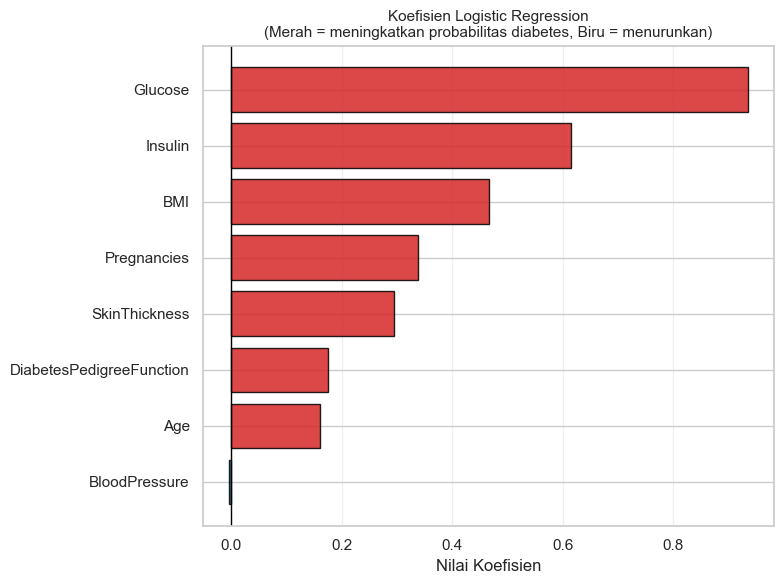


Koefisien Logistic Regression:
  Glucose                       : +0.9349  ↑ meningkatkan risiko
  Insulin                       : +0.6142  ↑ meningkatkan risiko
  BMI                           : +0.4661  ↑ meningkatkan risiko
  Pregnancies                   : +0.3372  ↑ meningkatkan risiko
  SkinThickness                 : +0.2950  ↑ meningkatkan risiko
  DiabetesPedigreeFunction      : +0.1747  ↑ meningkatkan risiko
  Age                           : +0.1598  ↑ meningkatkan risiko
  BloodPressure                 : -0.0042  ↓ menurunkan risiko


In [17]:
# Khusus Logistic Regression: tampilkan koefisien setiap fitur dalam bentuk bar chart horizontal.
# Koefisien positif menandakan fitur meningkatkan probabilitas diabetes, negatif sebaliknya.
feature_names = X.columns.tolist()
coefs = lr.coef_[0]

sorted_idx = np.argsort(coefs)
colors = ['#d62728' if c > 0 else '#1f77b4' for c in coefs[sorted_idx]]

fig, ax = plt.subplots(figsize=(8, 6))
bars = ax.barh(np.array(feature_names)[sorted_idx], coefs[sorted_idx],
               color=colors, edgecolor='black', alpha=0.85)
ax.axvline(0, color='black', linewidth=1)
ax.set_xlabel('Nilai Koefisien', fontsize=12)
ax.set_title('Koefisien Logistic Regression\n(Merah = meningkatkan probabilitas diabetes, Biru = menurunkan)', fontsize=11)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print("\nKoefisien Logistic Regression:")
for feat, coef in sorted(zip(feature_names, coefs), key=lambda x: abs(x[1]), reverse=True):
    direction = "↑ meningkatkan risiko" if coef > 0 else "↓ menurunkan risiko"
    print(f"  {feat:<30}: {coef:+.4f}  {direction}")

# 5. Analisis

### Jelaskan secara detail hasil analisis yang didapatkan dari eksperimen yang telah dilakukan. Bandingkan performa Gaussian Naive Bayes dan Logistic Regression berdasarkan hasil evaluasi. Pastikan analisis didasari oleh hasil eksperimen sendiri yang telah dilakukan.


Berdasarkan hasil eksperimen, diperoleh hasil evaluasi dari kedua model sebagai berikut:

| Model | Accuracy | Precision | Recall | F1-Score | AUC-ROC |
| --- | --- | --- | --- | --- | --- |
| GaussianNB | 0.7273 | 0.6034 | 0.6481 | 0.6250 | 0.8017 |
| LogisticRegression | 0.7078 | 0.5882 | 0.5556 | 0.5714 | 0.8263 |

### Accuracy dan F1-Score
GaussianNB memberikan hasil yang lebih baik dibandingkan Logistic Regression pada Accuracy dan F1-Score. GaussianNB memperoleh Accuracy sebesar 72.73% dan F1-Score sebesar 62.50%, sedangkan Logistic Regression memperoleh masing-masing 70.78% dan 57.14%.

F1-Score cukup penting untuk diperhatikan pada dataset ini karena jumlah data pada kelas diabetes dan non-diabetes tidak seimbang. Metrik ini mempertimbangkan Precision dan Recall secara bersamaan. Dari hasil tersebut, GaussianNB terlihat lebih baik dalam mengenali kasus diabetes positif secara keseluruhan.

### Precision dan Recall
GaussianNB juga memiliki Precision dan Recall yang lebih tinggi dibandingkan Logistic Regression. Precision GaussianNB mencapai 60.34% dan Recall sebesar 64.81%, sedangkan Logistic Regression memperoleh Precision 58.82% dan Recall 55.56%.

Untuk kasus prediksi diabetes, Recall menjadi salah satu metrik yang penting karena false negative berarti pasien yang sebenarnya memiliki diabetes justru diprediksi sebagai non-diabetes. Kesalahan seperti ini tentunya perlu diminimalkan. Dengan Recall yang lebih tinggi, GaussianNB lebih baik dalam menangkap kasus diabetes positif pada eksperimen ini.

### AUC-ROC
Walaupun GaussianNB lebih unggul pada sebagian besar metrik, Logistic Regression justru memiliki AUC-ROC yang lebih tinggi, yaitu 0.8263 dibandingkan 0.8017 pada GaussianNB.

AUC-ROC melihat kemampuan model dalam membedakan kelas positif dan negatif pada berbagai nilai threshold, bukan hanya pada threshold 0.5. Jadi, meskipun Logistic Regression menghasilkan Accuracy dan Recall yang lebih rendah pada threshold default, model ini sebenarnya memiliki kemampuan yang lebih baik dalam memberikan peringkat risiko antara pasien yang berpotensi diabetes dan yang tidak.

### Koefisien Logistic Regression
Dari hasil Logistic Regression, fitur yang memiliki pengaruh paling besar terhadap prediksi diabetes adalah Glucose dengan koefisien +0.9349 dan Insulin dengan koefisien +0.6142. Setelah itu terdapat BMI dengan koefisien +0.4661 dan Pregnancies dengan +0.3372.

Sementara itu, BloodPressure memiliki koefisien yang sangat kecil, yaitu -0.0042, sehingga pengaruhnya terhadap prediksi pada model ini relatif kecil.

Hasil tersebut cukup masuk akal karena kadar glukosa dan insulin memang memiliki hubungan yang kuat dengan kondisi diabetes. Jadi, fitur yang paling berpengaruh dari model juga masih sejalan dengan pengetahuan medis secara umum.

### Dampak Imbalanced Dataset
Dataset yang digunakan memiliki distribusi kelas yang tidak seimbang, yaitu sekitar 65.1% data non-diabetes dan 34.9% data diabetes. Kondisi ini dapat membuat model lebih mudah mengenali kelas mayoritas dibandingkan kelas diabetes yang jumlahnya lebih sedikit.

Hal tersebut dapat dilihat dari nilai Recall yang masih relatif rendah. Artinya, masih terdapat beberapa kasus diabetes yang belum berhasil dikenali oleh model. Untuk mengatasi masalah ini, dapat digunakan beberapa strategi tambahan seperti `class_weight='balanced'` atau teknik oversampling seperti SMOTE agar model lebih memperhatikan kelas diabetes.

# 6. Kesimpulan dan Saran

### Berikan kesimpulan dari eksperimen yang telah dilakukan. Saran dapat berupa rekomendasi untuk eksperimen selanjutnya, perbaikan model, atau hal-hal lain yang relevan dengan tugas ini.

### Kesimpulan

Berdasarkan hasil eksperimen, kedua model mampu melakukan klasifikasi diabetes dengan Accuracy sekitar 70% sampai 73%. Hasil ini cukup baik sebagai baseline, terutama karena dataset yang digunakan memiliki distribusi kelas yang tidak seimbang dan beberapa fitur mungkin masih mengandung noise.

GaussianNB memberikan hasil yang lebih baik pada Accuracy dan F1-Score, yaitu masing-masing 72.73% dan 62.50%. Selain itu, Recall GaussianNB juga lebih tinggi. Berdasarkan threshold default 0.5, GaussianNB menjadi model yang lebih baik untuk eksperimen ini.

Di sisi lain, Logistic Regression memiliki AUC-ROC yang lebih tinggi, yaitu 0.8263. Hal ini menunjukkan bahwa Logistic Regression memiliki kemampuan yang lebih baik dalam membedakan tingkat risiko pasien jika dilihat dari berbagai threshold. Model ini dapat menjadi pilihan yang menarik apabila output yang dibutuhkan berupa skor atau probabilitas risiko, bukan hanya keputusan diabetes atau non-diabetes.

Berdasarkan koefisien Logistic Regression, Glucose dan Insulin menjadi dua fitur yang paling berpengaruh dalam prediksi diabetes, kemudian diikuti oleh BMI dan Pregnancies. Hasil ini juga masih sejalan dengan pemahaman mengenai faktor yang berkaitan dengan diabetes.

Pada dataset yang digunakan, nilai 0 yang sebelumnya dianggap sebagai nilai tidak valid sudah dibersihkan. Oleh karena itu, tidak diperlukan proses imputasi untuk mengganti nilai tersebut. Meskipun demikian, pengecekan terhadap missing value tetap dilakukan sebagai bagian dari proses persiapan data.

### Saran
Beberapa hal yang dapat dicoba untuk meningkatkan hasil eksperimen adalah:
1. **Menangani imbalanced dataset**
Logistic Regression dapat menggunakan `class_weight='balanced'` agar lebih memperhatikan kelas diabetes. Selain itu, teknik seperti SMOTE juga dapat dicoba untuk menambah jumlah data pada kelas minoritas.

2. **Optimasi threshold**
Threshold 0.5 tidak selalu menjadi pilihan terbaik, terutama jika Recall lebih diutamakan. Threshold dapat diturunkan, misalnya ke sekitar 0.4, kemudian dibandingkan hasilnya untuk melihat apakah Recall meningkat tanpa menurunkan Precision terlalu jauh.

3. **Menggunakan cross-validation**
K-fold cross-validation, misalnya dengan k=5, dapat digunakan untuk mendapatkan gambaran performa model yang lebih stabil. Dengan cara ini, hasil evaluasi tidak hanya bergantung pada satu pembagian data train dan test.

4. **Feature engineering**
Fitur tambahan atau interaksi antarfitur dapat dicoba untuk membantu model menangkap hubungan yang lebih kompleks. Salah satu contohnya adalah membuat fitur interaksi seperti Glucose × BMI.

5. **Mencoba model lain**
Model seperti Random Forest atau XGBoost dapat digunakan sebagai pembanding. Dengan begitu, performa GaussianNB dan Logistic Regression dapat dibandingkan dengan model yang mampu menangkap hubungan non-linear dengan lebih baik.
